# Phân tích lý thuyết: Phát hiện ảnh trùng lặp bằng pHash

## 1. Hàm Băm pHash:

Trong bước phân tích thống kê tập dữ liệu, một nhiệm vụ quan trọng là xác định các ảnh bị trùng lặp hoặc gần như trùng lặp. Để thực hiện việc này, chúng ta sẽ sử dụng một kỹ thuật gọi là **Perceptual Hashing**, cụ thể là thuật toán **pHash**.

### 1.1. pHash là gì?

pHash là một thuật toán tạo ra một dấu vân tay kỹ thuật số - digital fingerprint cho một hình ảnh, dựa trên nội dung trực quan của nó. Điểm khác biệt cốt lõi của pHash so với các hàm băm mật mã (ví dụ: MD5, SHA-256) nằm ở mục đích sử dụng:

- **Hàm băm mật mã:** Dùng để kiểm tra sự toàn vẹn tuyệt đối. Thay đổi dù chỉ 1 pixel cũng sẽ tạo ra một mã băm hoàn toàn khác biệt.
- **Hàm băm pHash:** Dùng để kiểm tra sự tương đồng cảm nhận. Những thay đổi nhỏ, không ảnh hưởng đến nội dung chính của ảnh như thay đổi kích thước, nén file, chỉnh sáng nhẹ sẽ chỉ tạo ra một mã băm gần giống với mã băm gốc.

> **Nguyên tắc của pHash:** Những hình ảnh trông giống nhau sẽ có mã băm gần giống nhau.

### 1.2. Thuật toán pHash hoạt động như thế nào?

pHash không phải là một công thức toán học đơn lẻ, mà là một quy trình xử lý ảnh gồm nhiều bước. Phiên bản phổ biến nhất dựa trên biến đổi Cosine rời rạc (Discrete Cosine Transform - DCT) hoạt động như sau:

1.  **Giảm kích thước:** Ảnh được thu nhỏ về kích thước cố định rất nhỏ ví dụ như 32x32 pixels.
    *   *Mục đích:* Loại bỏ các chi tiết phức tạp và sự phụ thuộc vào độ phân giải gốc. Bước này buộc thuật toán phải tập trung vào cấu trúc tổng thể của ảnh.

2.  **Chuyển sang ảnh xám:** Ảnh được chuyển đổi sang thang độ xám (grayscale).
    *   *Mục đích:* Loại bỏ thông tin màu sắc, chỉ giữ lại thông tin về cường độ sáng. Điều này làm cho thuật toán trở nên bền vững trước các thay đổi về tông màu.

3.  **Tính toán DCT (Discrete Cosine Transform):** Áp dụng phép biến đổi DCT lên ma trận pixel 32x32.
    *   *Mục đích:* DCT là một kỹ thuật toán học giúp tách ảnh thành các thành phần tần số khác nhau. Các tần số thấp (đại diện cho cấu trúc chính, hình dạng lớn, sự thay đổi ánh sáng từ từ) sẽ được tập trung ở góc trên bên trái của ma trận kết quả.

4.  **Chắt lọc DCT:** Chỉ giữ lại một phần nhỏ (thường là 8x8) ở góc trên bên trái của ma trận DCT.
    *   *Mục đích:* Đây là bước chắt lọc thông tin quan trọng nhất. Chúng ta chỉ lấy 64 giá trị đại diện cho bản chất cốt lõi của ảnh và loại bỏ hết các chi tiết không cần thiết.

5.  **Tính giá trị trung bình:** Tính giá trị trung bình của 64 giá trị trong ma trận 8x8 vừa thu được.

6.  **Tạo mã băm nhị phân:** So sánh tuần tự 64 giá trị DCT với giá trị trung bình.
    *   Nếu một giá trị **lớn hơn hoặc bằng** trung bình, gán bit **`1`**.
    *   Nếu một giá trị **nhỏ hơn** trung bình, gán bit **`0`**.
    *   Kết quả là một chuỗi 64-bit (ví dụ: `11010010...`), đây chính là **mã pHash** của ảnh.

### 1.3. Cơ chế so sánh: Khoảng cách Hamming

pHash không so sánh trực tiếp hai ảnh. Thay vào đó, nó so sánh hai fingerprint 64-bit của chúng bằng một phép đo gọi là **Khoảng cách Hamming - Hamming Distance**.

> **Định nghĩa:** Khoảng cách Hamming là số lượng các vị trí bit khác nhau giữa hai chuỗi bit có cùng độ dài.

**Ví dụ:**
- Hash A: `10110010`
- Hash B: `11110110`
- So sánh từng bit, ta thấy chúng khác nhau ở vị trí thứ 2 và thứ 6. Do đó, Khoảng cách Hamming là **2**.

Nếu hai ảnh có cấu trúc cảm nhận tương tự nhau, mã pHash của chúng sẽ rất giống nhau, dẫn đến Khoảng cách Hamming rất nhỏ (gần bằng 0).

## 2. Diễn giải kết quả và lựa chọn ngưỡng tương đồng

### 2.1. Phân loại mức độ tương đồng

Dựa vào giá trị Khoảng cách Hamming, chúng ta có thể phân loại mức độ tương đồng giữa hai ảnh thành các cấp độ sau:

*   **Ảnh trùng tặp - Identical / Duplicate:**
    *   **Định nghĩa:** Khi khoảng cách Hamming **chính xác bằng 0**.
    *   **Ý nghĩa:** Chuỗi 64-bit của hai ảnh giống hệt nhau. Đây là hai bản sao của nhau về mặt cảm nhận, ví dụ như copy-paste, đổi tên file.

*   **Ảnh gần giống - Near-Duplicate / Similar:**
    *   **Định nghĩa:** Khi khoảng cách Hamming là một giá trị **nhỏ nhưng lớn hơn 0**.
    *   **Ý nghĩa:** Phần lớn cấu trúc cảm nhận của hai ảnh là như nhau. Một vài bit trong chuỗi băm bị thay đổi do các chỉnh sửa nhỏ như:
        - Thay đổi kích thước.
        - Nén ảnh với chất lượng khác nhau.
        - Thêm một watermark hoặc logo nhỏ.
        - Cropping một phần nhỏ.
        - Chỉnh sửa nhẹ về độ sáng hoặc màu sắc.

*   **Ảnh Khác biệt - Dissimilar:**
    *   **Định nghĩa:** Khi Khoảng cách Hamming là một giá trị **lớn**.
    *   **Ý nghĩa:** Cấu trúc tổng thể và nội dung chính của hai ảnh hoàn toàn khác nhau.

### 2.2. Phân tích về ngưỡng tương đồng - Threshold

Việc lựa chọn một **ngưỡng (threshold)** là cực kỳ quan trọng để tự động hóa việc phân loại. Đây là một sự đánh đổi giữa **độ chính xác (Precision)** và **độ bao phủ (Recall)**.

| Ngưỡng | Độ Chính Xác (Precision) | Độ Bao Phủ (Recall) | Rủi Ro |
| :--- | :--- | :--- | :--- |
| **Thấp (ví dụ: ≤ 3)** | Rất Cao | Thấp | Bỏ sót nhiều cặp gần giống (False Negatives) |
| **Trung bình (ví dụ: 4-7)** | Cao | Trung bình | Cân bằng giữa hai yếu tố |
| **Cao (ví dụ: ≥ 8)** | Thấp | Cao | Bao gồm cả các ảnh khác nhau (False Positives) |

Dựa trên kinh nghiệm và các tài liệu tham khảo, chúng ta có thể phân tích các khoảng ngưỡng như sau:

*   **Ngưỡng an toàn (`Khoảng cách ≤ 5`):**
    *   Đây là vùng có độ tin cậy rất cao. Các cặp ảnh trong khoảng này gần như chắc chắn là biến thể của cùng một ảnh gốc. Đây là ngưỡng khởi đầu được khuyến nghị cho hầu hết các tác vụ làm sạch dữ liệu.

*   **Vùng xám (`6 ≤ Khoảng cách ≤ 10`):**
    *   Đây là vùng có sự mơ hồ. Các cặp ảnh có thể là ảnh gần giống đã qua chỉnh sửa nhiều, hoặc là hai ảnh khác nhau nhưng có bố cục tình cờ tương tự. Việc sử dụng ngưỡng trong khoảng này đòi hỏi phải kiểm tra thủ công một vài mẫu để đánh giá.

*   **Ngưỡng khác biệt (`Khoảng cách > 10`):**
    *   Có thể tự tin kết luận rằng đây là hai ảnh riêng biệt, không liên quan về mặt nội dung.

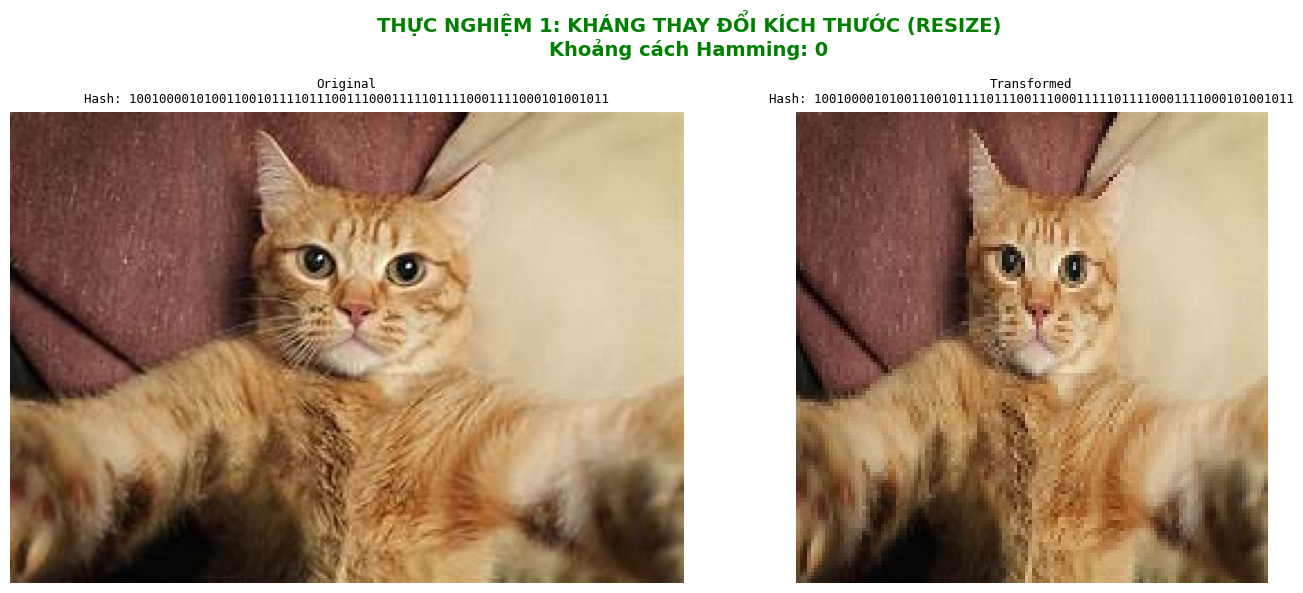

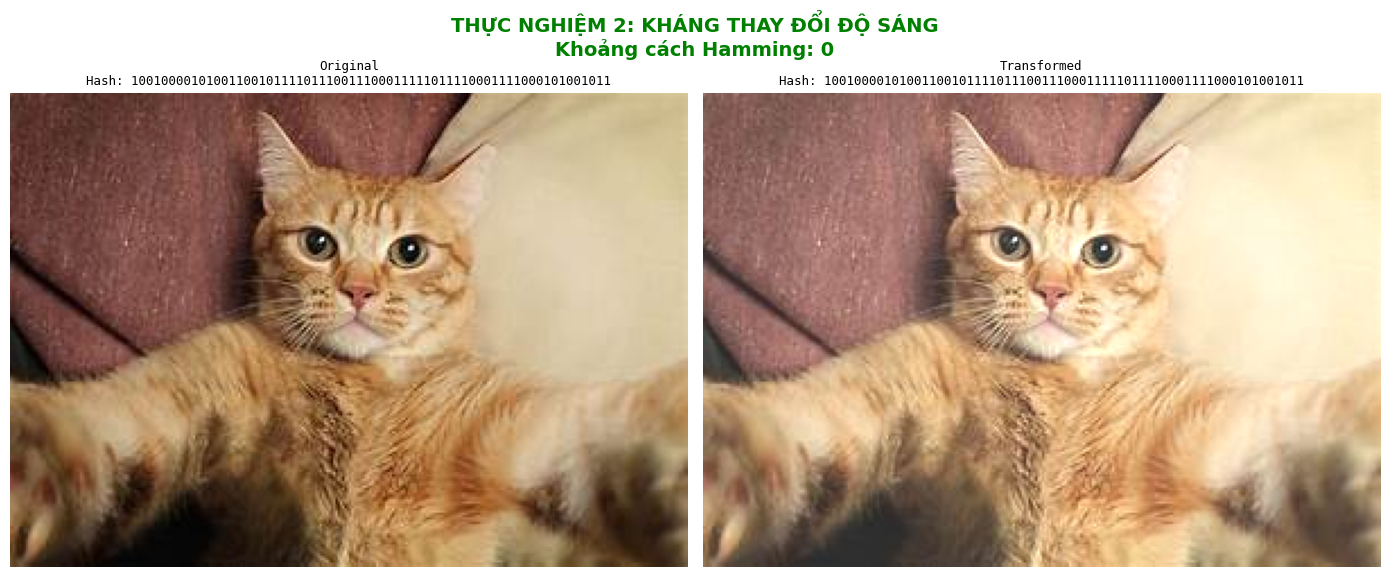

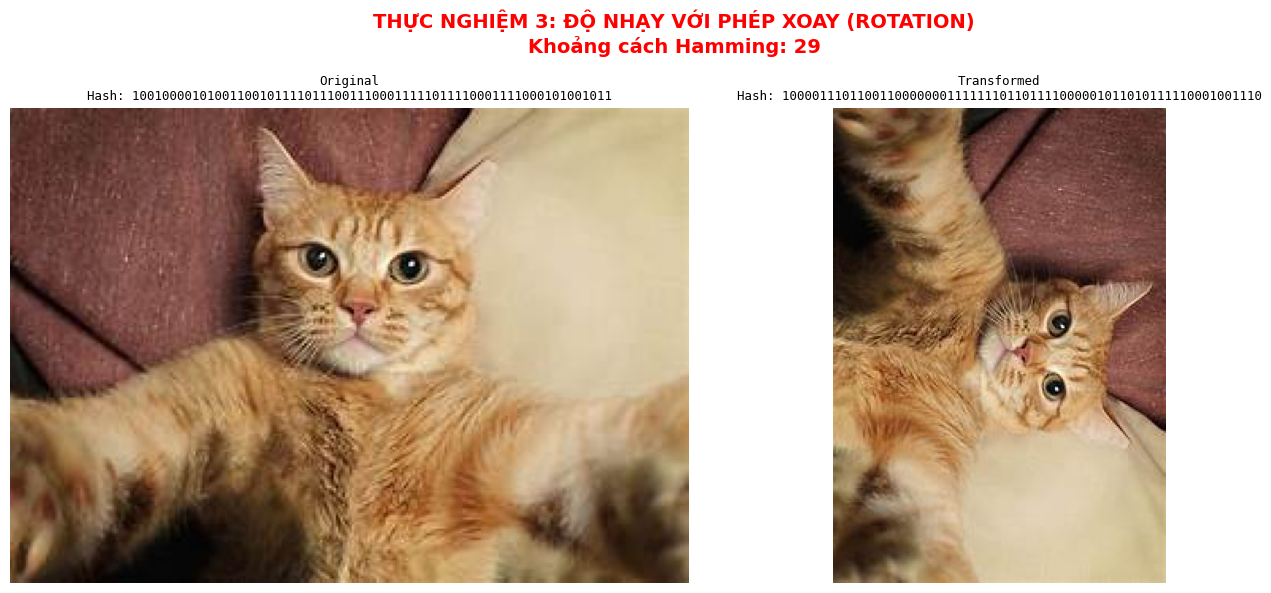

In [1]:
import sys
import os
import cv2
import matplotlib.pyplot as plt
import numpy as np

# Thiết lập đường dẫn hệ thống để import core logic
sys.path.append(os.path.abspath(os.path.join('..', 'src')))
from image.analysis_deduplicate import ImageDeduplication

# Khởi tạo đối tượng phân tích
deduper = ImageDeduplication(hash_size=8, similarity_threshold=10)

def visualize_hash_impact(img1, img2, title):
    """Trực quan hóa tác động của biến đổi ảnh đến mã băm pHash"""
    img1_rgb = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)
    img2_rgb = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)
    
    # Tính toán mã băm pHash
    hash1 = deduper._calculate_phash(img1)
    hash2 = deduper._calculate_phash(img2)
    distance = deduper._hamming_distance(hash1, hash2)
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    color = 'green' if distance <= deduper._threshold else 'red'
    fig.suptitle(f"{title}\nKhoảng cách Hamming: {distance}", fontsize=14, fontweight='bold', color=color)
    
    # Hiển thị ảnh kèm chuỗi Hash
    axes[0].imshow(img1_rgb)
    axes[0].set_title(f"Original\nHash: {hash1}", fontsize=9, family='monospace')
    axes[0].axis('off')
    
    axes[1].imshow(img2_rgb)
    axes[1].set_title(f"Transformed\nHash: {hash2}", fontsize=9, family='monospace')
    axes[1].axis('off')
    
    plt.tight_layout()
    plt.show()

# Thực hiện thực nghiệm trên ảnh mẫu
sample_path = "../data/small/cat/1.jpeg"
if os.path.exists(sample_path):
    img_org = cv2.imread(sample_path)
    visualize_hash_impact(img_org, cv2.resize(img_org, (128, 128)), "THỰC NGHIỆM 1: KHÁNG THAY ĐỔI KÍCH THƯỚC (RESIZE)")
    visualize_hash_impact(img_org, cv2.convertScaleAbs(img_org, alpha=1, beta=40), "THỰC NGHIỆM 2: KHÁNG THAY ĐỔI ĐỘ SÁNG")
    visualize_hash_impact(img_org, cv2.rotate(img_org, cv2.ROTATE_90_CLOCKWISE), "THỰC NGHIỆM 3: ĐỘ NHẠY VỚI PHÉP XOAY (ROTATION)")

# Đánh giá Ưu và Nhược điểm của thuật toán pHash

Dựa trên các kết quả trực quan hóa ở trên, ta có thể rút ra những đánh giá sau về thuật toán pHash:

**1. Ưu điểm nổi bật:**
Thuật toán hoạt động rất tốt với các biến đổi giữ nguyên cấu trúc không gian của ảnh.
* **Kháng thay đổi kích thước (Resize/Nén):** Khi thu nhỏ độ phân giải ảnh gốc xuống 50%, chuỗi mã băm (64-bit) sinh ra gần như không đổi (Khoảng cách Hamming = 0). Điều này cho thấy thuật toán rất phù hợp để tìm các ảnh bị nén hoặc đổi kích thước trên mạng.
* **Kháng thay đổi ánh sáng/màu sắc nhẹ:** Khi tăng độ sáng của ảnh lên đáng kể, khoảng cách Hamming vẫn bằng 0. Do pHash chuyển ảnh về thang độ xám (grayscale) và chỉ lấy các tần số thấp của biến đổi DCT, nó không bị nhiễu bởi các thay đổi về cường độ sáng hay tông màu.

**2. Nhược điểm:**
* **Rất nhạy cảm với các biến đổi hình học (Đặc biệt là xoay - Rotation):** Như hình minh họa, khi ta xoay ảnh 90 độ, dù nội dung đối với mắt người là giống hệt nhau, chuỗi pHash bị xáo trộn hoàn toàn (Khoảng cách Hamming vọt lên 29, vượt xa ngưỡng cho phép). Thuật toán sẽ coi đây là 2 ảnh hoàn toàn khác biệt.
* *Giải thích:* Phép biến đổi ma trận DCT phụ thuộc chặt chẽ vào vị trí các pixel theo trục tọa độ X-Y. Việc xoay hoặc lật ảnh làm thay đổi hoàn toàn cấu trúc ma trận tần số không gian, dẫn đến sai lệch hash.

[INFO] Đang nạp tập dữ liệu...
[SUCCESS] Đã nạp 228 ảnh.
[PROCESS] Đang quét ảnh trùng lặp...


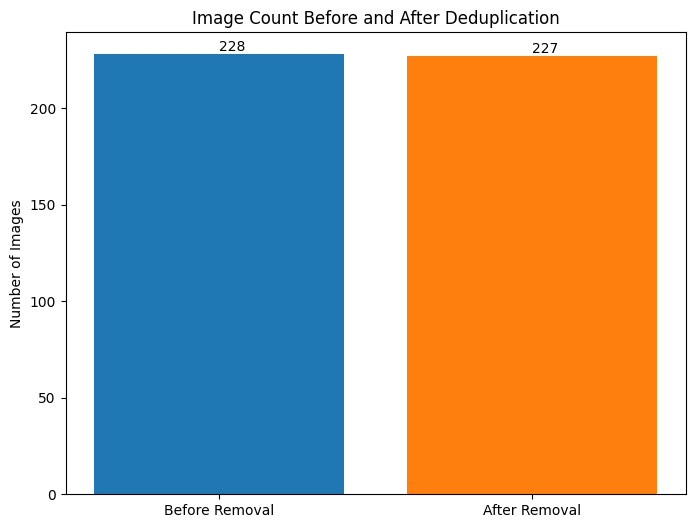


--- Image Deduplication Analysis Log ---
1. Processing Step: Image Deduplication Analysis
2. Dataset Path: ../data/small
3. Status: Success
4. Result Information:
	- Similarity Threshold (Hamming distance): 10
	- Initial Image Count: 228
	- Duplicates Found: 1
	- Estimated Final Image Count: 227
----------------------------------------

[RESULT] Tìm thấy 1 ảnh trùng lặp.
Cặp trùng lặp: e83db50a28f1073ed1584d05fb1d4e9fe777ead218ac104497f5c978a6ebb3bf_640.jpg <-> e83cb60c2df1033ed1584d05fb1d4e9fe777ead218ac104497f5c978a6eab2b0_640.jpg
 > Hash A: 1100001101100011000111000101110011100011101101111101111000111011
 > Hash B: 1100001101100011000111001101110011100011101101111101111000111011

--- Remove Duplication Preprocessing Log ---
1. Processing Step: Preprocessing - Remove Duplicates
2. Status: Success
	- Initial Image Count: 228
	- Files Copied to '../data/de-duplicate': 1
	- Number of Images Removed from RAM: 1
	- Final Image Count: 227
------------------------------------------



In [2]:
from image.dataset import ImageDataset
from image.preprocessing_remove_duplication import RemoveDuplication

# 1. Khởi tạo và nạp dữ liệu chuẩn hóa
print("[INFO] Đang nạp tập dữ liệu...")
dataset_path = "../data/small"
dataset = ImageDataset(dataset_path)

# Nạp ảnh thủ công để đảm bảo tính đồng nhất (128x128) tránh lỗi inhomogeneous
X, Y, paths, names = [], [], [], []
class_map = {d: i for i, d in enumerate(sorted(os.listdir(dataset_path))) if os.path.isdir(os.path.join(dataset_path, d))}

for c_name, c_idx in class_map.items():
    c_dir = os.path.join(dataset_path, c_name)
    for f in os.listdir(c_dir):
        if f.lower().endswith(('.jpg', '.jpeg', '.png')):
            p = os.path.join(c_dir, f)
            img = cv2.imread(p)
            if img is not None:
                X.append(cv2.resize(img, (128, 128)))
                Y.append(c_idx); paths.append(p); names.append(f)

dataset._images, dataset._labels, dataset._paths, dataset._file_names = X, Y, paths, names
dataset._size = len(X); dataset._shape = (len(X), 128, 128, 3)
print(f"[SUCCESS] Đã nạp {dataset._size} ảnh.")

# 2. Phát hiện trùng lặp
print("[PROCESS] Đang quét ảnh trùng lặp...")
deduper.run(dataset)

# 3. Hiển thị mẫu cặp ảnh trùng kèm chuỗi Hash
if len(deduper._indices_to_remove) > 0:
    print(f"[RESULT] Tìm thấy {len(deduper._indices_to_remove)} ảnh trùng lặp.")
    all_imgs, _ = dataset.images
    hashes = [deduper._calculate_phash(img) for img in all_imgs]
    
    count = 0
    for r_idx in list(deduper._indices_to_remove):
        if count >= 2: break
        r_hash = hashes[r_idx]
        for k_idx in range(dataset._size):
            if k_idx not in deduper._indices_to_remove:
                dist = deduper._hamming_distance(r_hash, hashes[k_idx])
                if dist <= deduper._threshold:
                    print(f"Cặp trùng lặp: {dataset._file_names[k_idx]} <-> {dataset._file_names[r_idx]}")
                    print(f" > Hash A: {hashes[k_idx]}\n > Hash B: {r_hash}")
                    count += 1; break

# 4. Loại bỏ ảnh trùng lặp
output_dir = "../data/de-duplicate"
remover = RemoveDuplication(indices_to_remove=deduper._indices_to_remove, output_dir=output_dir)
remover.run(dataset)

# Đề xuất các cách cải thiện thuật toán Deduplication

Để khắc phục nhược điểm của pHash và tăng độ chính xác cho hệ thống lọc ảnh trùng lặp, ta có thể xem xét các phương án sau:

**1. Điều chỉnh ngưỡng - Threshold:**
* Ngưỡng Hamming hiện tại (ví dụ: 10) có thể quá cứng nhắc. Ta có thể áp dụng ngưỡng động tùy thuộc vào đặc thù của tập dữ liệu (ảnh y tế cần ngưỡng thấp $\le 2$, ảnh mạng xã hội có thể để ngưỡng $\le 10$).
* Cần thực hiện kiểm thử trên một tập dữ liệu nhỏ để vẽ đường cong Trade-off giữa Precision và Recall, từ đó chọn ra ngưỡng tối ưu nhất.

**2. Kết hợp với các loại Hash khác:**
* **Kết hợp aHash (Average Hash) và dHash (Difference Hash):** Mỗi thuật toán hash nhạy cảm với một loại nhiễu khác nhau. dHash chạy cực nhanh và nhận dạng cấu trúc cạnh tốt, trong khi pHash nhận dạng tổng thể tốt. Ta có thể dùng dHash để lọc sơ bộ, sau đó dùng pHash để kiểm tra kỹ lại.

**3. Tiền xử lý chống xoay:**
* Trước khi đưa qua pHash, có thể dùng các thuật toán phát hiện hướng của ảnh, tự động xoay ảnh về một góc tiêu chuẩn.
* Hoặc đơn giản hơn: Tính pHash cho cả 4 góc xoay ($0^\circ, 90^\circ, 180^\circ, 270^\circ$) của ảnh gốc và so sánh. Nếu bất kỳ góc nào có khoảng cách Hamming nhỏ hơn ngưỡng, ta coi như trùng lặp (Cách này tốn chi phí tính toán gấp 4 lần).